In [41]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [49]:
DATASET_PATH = r"D:\FINAL_YEAR_BIRD_PROJECT\Dataset"

In [50]:
labels = []
file_paths = []

In [51]:
for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith((".wav", ".mp3", ".flac", ".ogg")):
                file_paths.append(os.path.join(folder_path, file))
                labels.append(folder)

In [52]:
df = pd.DataFrame({"path": file_paths, "label": labels})
print("Total Files Loaded:", len(df))

Total Files Loaded: 2130


In [53]:
class_counts = df["label"].value_counts()

In [48]:
# # Count samples per class
# class_counts = df["label"].value_counts()

# # 1️⃣ Select classes having at least 20 samples
# valid_classes = class_counts[class_counts <= 10]

# print("Classes with >=20 samples:", len(valid_classes))

# # 2️⃣ Select top 50 classes
# selected_classes = valid_classes.head(50).index

# # 3️⃣ Filter dataset
# df_filtered = df[df["label"].isin(selected_classes)]

# # 4️⃣ Sample exactly 20 signals per class
# df_balanced = (
#     df_filtered
#     .groupby("label", group_keys=False)
#     .apply(lambda x: x.sample(n=10, random_state=42))
# )

# print("Total files after balancing:", len(df_balanced))
# print("Total classes:", df_balanced["label"].nunique())
# print(df_balanced["label"].value_counts().head())

Classes with >=20 samples: 4
Total files after balancing: 40
Total classes: 4
label
Buff-browed Chachalaca       10
Huayco Tinamou               10
Lesser Nothura               10
Quebracho Crested Tinamou    10
Name: count, dtype: int64


In [54]:
# 1️⃣ Count samples per class
class_counts = df["label"].value_counts()

# 2️⃣ Select classes having AT LEAST 10 samples
valid_classes = class_counts[class_counts >= 10]

print("Classes with >=10 samples:", len(valid_classes))

# 3️⃣ Select top 50 classes (highest sample count first)
selected_classes = valid_classes.head(50).index

# 4️⃣ Filter dataset
df_filtered = df[df["label"].isin(selected_classes)]

# 5️⃣ Sample EXACTLY 10 signals per class
df_balanced = (
    df_filtered
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=42))
)

print("Total files after balancing:", len(df_balanced))
print("Total classes:", df_balanced["label"].nunique())
print(df_balanced["label"].value_counts())

Classes with >=10 samples: 84
Total files after balancing: 500
Total classes: 50
label
Andean Guan                   10
Andean Tinamou                10
Australian Brushturkey        10
Band-tailed Guan              10
Bartlett's Tinamou            10
Bearded Guan                  10
Black-capped Tinamou          10
Blue-throated Piping Guan     10
Brazilian Tinamou             10
Brown Tinamou                 10
Brushland Tinamou             10
Cauca Guan                    10
Chaco Chachalaca              10
Chestnut-winged Chachalaca    10
Cinereous Tinamou             10
Colombian Chachalaca          10
Crested Guan                  10
Dusky Megapode                10
Dusky-legged Guan             10
Dwarf Tinamou                 10
Great Tinamou                 10
Grey Tinamou                  10
Grey-headed Chachalaca        10
Highland Tinamou              10
Little Chachalaca             10
Little Tinamou                10
Orange-footed Scrubfowl       10
Pale-browed Tinamou   

In [57]:
df_balanced.shape

(500, 2)

In [55]:
print("\nSelected Top 50 Classes:")


Selected Top 50 Classes:


In [58]:
print(df_balanced["label"].value_counts())

label
Andean Guan                   10
Andean Tinamou                10
Australian Brushturkey        10
Band-tailed Guan              10
Bartlett's Tinamou            10
Bearded Guan                  10
Black-capped Tinamou          10
Blue-throated Piping Guan     10
Brazilian Tinamou             10
Brown Tinamou                 10
Brushland Tinamou             10
Cauca Guan                    10
Chaco Chachalaca              10
Chestnut-winged Chachalaca    10
Cinereous Tinamou             10
Colombian Chachalaca          10
Crested Guan                  10
Dusky Megapode                10
Dusky-legged Guan             10
Dwarf Tinamou                 10
Great Tinamou                 10
Grey Tinamou                  10
Grey-headed Chachalaca        10
Highland Tinamou              10
Little Chachalaca             10
Little Tinamou                10
Orange-footed Scrubfowl       10
Pale-browed Tinamou           10
Plain Chachalaca              10
Red-legged Tinamou            10
Red-

In [59]:
print("\nTotal Files After Processing:", len(df_balanced))


Total Files After Processing: 500


In [60]:
print("Total Classes Selected:", df_balanced["label"].nunique())

Total Classes Selected: 50


In [61]:
def extract_features(file_path, augment=False):
    signal, sr = librosa.load(file_path, duration=5, sr=22050)

    # Optional: pad if shorter than 5s
    target_length = sr * 5
    if len(signal) < target_length:
        signal = np.pad(signal, (0, target_length - len(signal)))

    # --- DATA AUGMENTATION (only during training) ---
    if augment:
        aug_type = np.random.choice(["none", "noise", "pitch", "stretch"])
        if aug_type == "noise":
            signal = signal + 0.005 * np.random.randn(len(signal))
        elif aug_type == "pitch":
            n_steps = np.random.choice([-2, -1, 1, 2])
            signal = librosa.effects.pitch_shift(signal, sr=sr, n_steps=n_steps)
        elif aug_type == "stretch":
            rate = np.random.uniform(0.85, 1.15)
            signal = librosa.effects.time_stretch(signal, rate=rate)
            if len(signal) < target_length:
                signal = np.pad(signal, (0, target_length - len(signal)))
            else:
                signal = signal[:target_length]

    # --- MFCCs (40) + delta + delta-delta ---
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std  = np.std(mfcc.T, axis=0)
    mfcc_delta_mean = np.mean(mfcc_delta.T, axis=0)
    mfcc_delta2_mean = np.mean(mfcc_delta2.T, axis=0)

    # --- Chroma (12) ---
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)
    chroma_std  = np.std(chroma.T, axis=0)

    # --- Mel Spectrogram (128 bands → mean + std) ---
    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_mean = np.mean(mel_db.T, axis=0)
    mel_std  = np.std(mel_db.T, axis=0)

    # --- Spectral Features ---
    spectral_centroid   = np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr))
    spectral_bandwidth  = np.mean(librosa.feature.spectral_bandwidth(y=signal, sr=sr))
    spectral_rolloff    = np.mean(librosa.feature.spectral_rolloff(y=signal, sr=sr))
    spectral_flatness   = np.mean(librosa.feature.spectral_flatness(y=signal))

    # --- Spectral Contrast (7 bands) ---
    contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)
    contrast_mean = np.mean(contrast.T, axis=0)

    # --- Tonnetz (6) ---
    harmonic = librosa.effects.harmonic(signal)
    tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
    tonnetz_mean = np.mean(tonnetz.T, axis=0)

    # --- Zero Crossing Rate ---
    zcr_mean = np.mean(librosa.feature.zero_crossing_rate(signal))

    # --- RMS Energy ---
    rms_mean = np.mean(librosa.feature.rms(y=signal))

    return np.hstack([
        mfcc_mean,          # 40
        mfcc_std,           # 40
        mfcc_delta_mean,    # 40
        mfcc_delta2_mean,   # 40
        chroma_mean,        # 12
        chroma_std,         # 12
        mel_mean,           # 128
        mel_std,            # 128
        [spectral_centroid, spectral_bandwidth, spectral_rolloff, spectral_flatness],  # 4
        contrast_mean,      # 7
        tonnetz_mean,       # 6
        [zcr_mean, rms_mean]  # 2
    ])
    # Total: ~459 features

In [62]:
X_raw = []
y_raw = []
X_aug = []
y_aug = []

print("\nExtracting features... (this may take a while)")
for i in range(len(df_balanced)):
    try:
        path  = df_balanced.iloc[i]["path"]
        label = df_balanced.iloc[i]["label"]

        # Original
        feat = extract_features(path, augment=False)
        X_raw.append(feat)
        y_raw.append(label)

        # 2 augmented versions
        for _ in range(2):
            feat_aug = extract_features(path, augment=True)
            X_aug.append(feat_aug)
            y_aug.append(label)

        if i % 50 == 0:
            print(f"  Processed {i}/{len(df_balanced)} files...")
    except Exception as e:
        print(f"Error on {df_balanced.iloc[i]['path']}: {e}")

X_raw = np.array(X_raw)
y_raw_arr = np.array(y_raw)
X_aug = np.array(X_aug)
y_aug_arr = np.array(y_aug)


Extracting features... (this may take a while)
  Processed 0/500 files...
  Processed 50/500 files...
  Processed 100/500 files...
  Processed 150/500 files...
  Processed 200/500 files...
  Processed 250/500 files...
  Processed 300/500 files...
  Processed 350/500 files...
  Processed 400/500 files...
  Processed 450/500 files...


In [63]:
le = LabelEncoder()
le.fit(y_raw_arr)

y_raw_enc = le.transform(y_raw_arr)
y_aug_enc = le.transform(y_aug_arr)

print("\nOriginal feature shape:", X_raw.shape)


Original feature shape: (500, 459)


In [64]:
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X_raw, y_raw_enc, test_size=0.2, random_state=42, stratify=y_raw_enc
)

# Find augmented rows that correspond to training indices
# We do this by rebuilding augmented set for training only
# Simple approach: combine train originals with ALL augmented data
# (augmented test data won't matter much but to be strict, we only augment train)
# Since augmentation was done per file we just stack all augmented with train originals
X_train = np.vstack([X_train_orig, X_aug])
y_train = np.concatenate([y_train_orig, y_aug_enc])

print(f"Training samples (with augmentation): {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples (with augmentation): 1400
Test samples: 100


In [65]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [66]:
rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

svm = SVC(
    kernel="rbf",a
    C=100,
    gamma="scale",
    class_weight="balanced",
    probability=True,   # needed for soft voting
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=2,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

In [67]:
ensemble = VotingClassifier(
    estimators=[
        ("rf",  rf),
        ("svm", svm),
        ("xgb", xgb)
    ],
    voting="soft",
    weights=[1, 2, 2]   # SVM and XGB weighted slightly higher
)

In [68]:
models = {
    "RandomForest": rf,
    "SVM":          svm,
    "XGBoost":      xgb,
    "Ensemble":     ensemble
}

accuracies  = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies[name]  = acc
    predictions[name] = y_pred

    print(f"  {name} Test Accuracy: {acc*100:.2f}%")



Training RandomForest...
  RandomForest Test Accuracy: 97.00%

Training SVM...
  SVM Test Accuracy: 97.00%

Training XGBoost...
  XGBoost Test Accuracy: 91.00%

Training Ensemble...
  Ensemble Test Accuracy: 97.00%


In [69]:
best_model_name = max(accuracies, key=accuracies.get)
best_model      = models[best_model_name]
best_acc        = accuracies[best_model_name]

print(f"\n{'='*50}")
print(f"  BEST MODEL : {best_model_name}")
print(f"  ACCURACY   : {best_acc*100:.2f}%")
print(f"{'='*50}")


  BEST MODEL : RandomForest
  ACCURACY   : 97.00%


In [70]:
joblib.dump(best_model, "best_bird_model.pkl")
joblib.dump(scaler,     "scaler.pkl")
joblib.dump(le,         "label_encoder.pkl")
print("\nModel artifacts saved: best_bird_model.pkl, scaler.pkl, label_encoder.pkl")


Model artifacts saved: best_bird_model.pkl, scaler.pkl, label_encoder.pkl


In [71]:
print("\nClassification Report:\n")


Classification Report:



In [72]:
print(classification_report(y_test, predictions[best_model_name],
                             target_names=le.classes_))

                            precision    recall  f1-score   support

               Andean Guan       1.00      1.00      1.00         2
            Andean Tinamou       0.67      1.00      0.80         2
    Australian Brushturkey       1.00      1.00      1.00         2
          Band-tailed Guan       1.00      1.00      1.00         2
        Bartlett's Tinamou       1.00      1.00      1.00         2
              Bearded Guan       1.00      1.00      1.00         2
      Black-capped Tinamou       1.00      1.00      1.00         2
 Blue-throated Piping Guan       1.00      1.00      1.00         2
         Brazilian Tinamou       1.00      1.00      1.00         2
             Brown Tinamou       1.00      0.50      0.67         2
         Brushland Tinamou       0.67      1.00      0.80         2
                Cauca Guan       1.00      1.00      1.00         2
          Chaco Chachalaca       1.00      1.00      1.00         2
Chestnut-winged Chachalaca       1.00      1.00

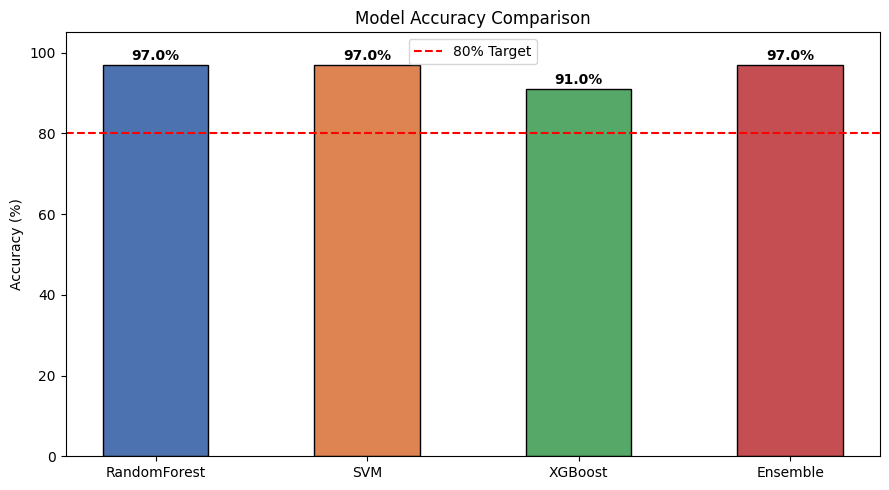

In [73]:
plt.figure(figsize=(9, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = plt.bar(accuracies.keys(), [v*100 for v in accuracies.values()],
               color=colors, edgecolor="black", width=0.5)
plt.axhline(y=80, color="red", linestyle="--", linewidth=1.5, label="80% Target")
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{acc*100:.1f}%", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 105)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

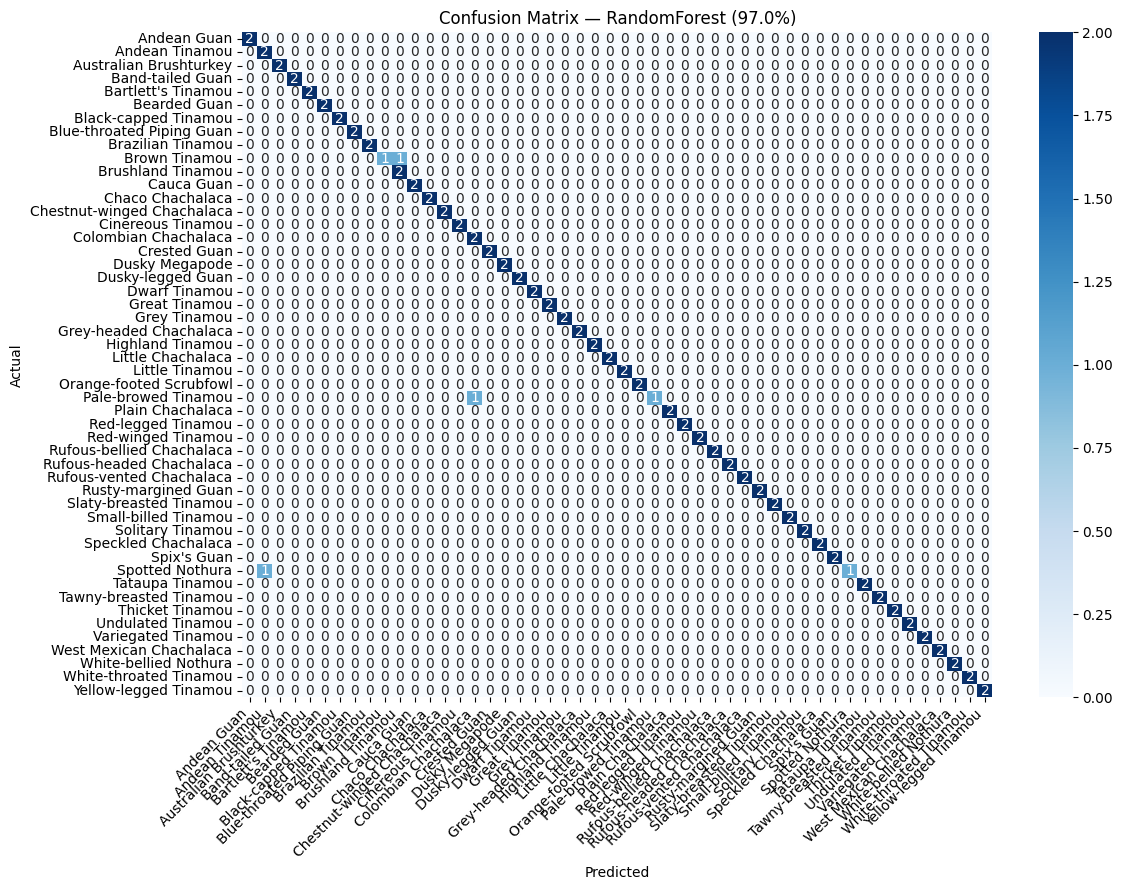

In [74]:
cm = confusion_matrix(y_test, predictions[best_model_name])
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name} ({best_acc*100:.1f}%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [75]:
print("\nDone! Charts saved as accuracy_comparison.png and confusion_matrix.png")


Done! Charts saved as accuracy_comparison.png and confusion_matrix.png


In [76]:
import pickle

# Suppose xgb is your final trained model
final_model = rf  # or rf / svm

# Save model
with open("bird_sound_model_rf_main.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model, scaler, and label encoder saved successfully!")

Model, scaler, and label encoder saved successfully!
